# Quantum Amplitude Amplification, Estimation and Grover Search

In this tutorial, we shall introduce ourselves to algorithms that have the following common main principle: manipulating amplitudes of quantum states. The first part will deal with amplitude amplification (QAA), and the second part will discuss amplitude estimation (QAE).

---

## Part I: Quantum Amplitude Amplification and Grover Search

Quantum amplitude amplification is an algorithm that amplifies the amplitude of a particular state in a superposition state.  
It is the core concept behind the design of Grover's algorithm.

### 1.1. Amplitude Amplification Algorithm (QAA)

Regarding the word "amplitude", the coefficients for each state are called **amplitude** and the probability is called **probability amplitude**.

The main idea behind amplifying amplitudes is to increase the coefficient of a particular quantum state via some operations on a superposition state, as demonstrated below:

$$
H \lvert 0 \rangle \otimes H \lvert 0 \rangle = \frac{1}{2} (\lvert 00 \rangle + \lvert 01 \rangle + \lvert10 \rangle + \lvert 11 \rangle) \xrightarrow{\text{Amplitude amplification}} \lvert 00 \rangle
$$

In this case, the probability amplitudes on the left side of the arrow are all $1/4$, while the state on the right side has probability amplitude $1$ for $\lvert 00\rangle$.
This means that the probability of measuring the state $\lvert 00\rangle$ has been _amplified_ from $1/4$ to $1$, thus explaining the name "QAA".

The following figure illustrates how the algorithm works on quantum states.

<img width="30%" src="https://upload.wikimedia.org/wikipedia/commons/1/16/Grovers_algorithm_geometry.png">

Ref: https://en.wikipedia.org/wiki/Grover%27s_algorithm

First, let's explain the symbols appearing in the diagram above.

+ Suppose $\lvert s\rangle$ is an arbitrary initial state.
For example, $\lvert s\rangle$ can be the uniform superposition of all $2^n$ possible states on $n$ qubits. Such an initial state is commonly used in Grover's algorithm.

$$
\lvert s \rangle = \otimes^n  H  \lvert 0 \rangle =\frac{1}{\sqrt{2^n}}\sum^{2^n}_{x\in \{0, 1\}^n}\lvert x \rangle
$$

+ Of all these states, $\lvert \omega\rangle$ is a particular state we want to amplify. Suppose that $\lvert \omega\rangle$ is the following state, with a $1$ at the $x$'th position and $0$ elsewhere:

$$
\lvert \omega \rangle = \frac 1{\sqrt{2^n}}\lvert 00...010...00\rangle
$$

(Strictly speaking, $\omega$ is not a quantum state as defined above since its norm is not $1$, but we use this notation only to simplify our calculations.)

+ Let $\lvert s'\rangle = \lvert s\rangle-\lvert \omega\rangle$, then it can be seen that the vectors $s'$ and $\omega$ are perpendicular.

$$
\lvert s' \rangle = \lvert s \rangle - \lvert \omega \rangle = \lvert \omega^{\perp} \rangle
$$

+ $U_{\omega}$ is a matrix that inverts $\psi$ on the $\lvert s'\rangle$ axis.
In other words, rotate $\psi$ by $-\phi$.

$$
U_{\omega} \lvert \psi \rangle = \cos(-\phi) {\lvert s' \rangle} + \sin(-\phi) {\lvert \omega \rangle} = \cos(\phi) {\lvert s' \rangle} - \sin(\phi) {\lvert \omega \rangle}
$$

+ $U_s$ is a matrix that inverts $\psi$ around $\lvert s\rangle$.

$$
U_s \lvert \psi \rangle = \cos \bigg\{ \frac{\theta}{2} + \big(\frac{\theta}{2} - \phi \big) \bigg\} {\lvert s' \rangle} + \sin \bigg\{ \frac{\theta}{2} + \big(\frac{\theta}{2} - \phi \big) \bigg\}{\lvert \omega \rangle} = \cos(\theta - \phi){\lvert s' \rangle} + \sin(\theta - \phi){\lvert \omega \rangle}
$$

### 1.2. Outline of QAA

The algorithm is outlined below.

1. Invert $\lvert s\rangle$ around $\lvert s' \rangle$ using $U_{\omega}$. Mathematically, $U_{\omega}$ flips the sign of $\lvert \omega\rangle$ in the uniform superposition $\lvert s\rangle$.

2. Invert $U_{\omega}\lvert s\rangle$ around $\lvert s\rangle$ using $U_s$.

We will explain the above process in detail.

#### 1. Invert around $\lvert s' \rangle$

Using $\theta$ as shown in the figure above, we describe $\lvert s \rangle$ as following.

$$
\lvert s \rangle = \cos\bigl(\frac{\theta}{2}\bigr){\lvert s' \rangle} - \sin\bigl(\frac{\theta}{2}\bigr) {\lvert \omega \rangle}
$$

The coefficients are given by:

$$
\cos\bigl( \frac{\theta}{2} \bigr) = \sqrt{\frac{2^n-1}{2^n}},\ \ \ \  \sin\bigl( \frac{\theta}{2} \bigr) = \sqrt{\frac{1}{2^n}}
$$

Using $U_{\omega}$, fold $\lvert s \rangle$ around $\lvert s' \rangle$.  
From the above figure, described as follows

$$
U_{\omega} \lvert s \rangle = \cos\bigl(-\frac{\theta}{2}\bigr){\lvert s' \rangle} + \sin\bigl(-\frac{\theta}{2}\bigr){\lvert \omega \rangle} = \cos\bigl(\frac{\theta}{2}\bigr){\lvert s' \rangle} - \sin\bigl(\frac{\theta}{2}\bigr){\lvert \omega \rangle}
$$

Since we are only working on $\lvert \omega \rangle$ for this operation, we can see that $U_{\omega}$ flips the sign of $\lvert \omega\rangle$ in the uniform superposition $\lvert s\rangle$. It is called the _Oracle_.

#### 2. Invert around $\lvert s \rangle$
Using $U_s$, fold $U_{\omega}\lvert s \rangle$ around $\lvert s \rangle$.

$$
U_s U_{\omega} \lvert s\rangle = U_s\biggl( \cos\bigl(-\frac{\theta}{2}\bigr){\lvert s' \rangle} + \sin\bigl(-\frac{\theta}{2}\bigr){\lvert \omega \rangle}  \biggr)
$$

Since we need to rotate $2\theta$ here,

$$
U_s U_{\omega} \lvert s\rangle =  \cos\bigl(\frac{3}{2}\theta\bigr){\lvert s' \rangle} + \sin\bigl(\frac{3}{2}\theta\bigr){\lvert \omega \rangle}
$$

Specifically, $\cos$ and $\sin$ are obtained from the additive theorem.

$$
\cos \frac{3}{2}\theta = \bigl( 1-\frac{4}{2^n} \bigr) \sqrt{\frac{2^n-1}{2^n}},\ \ \ \ \sin \frac{3}{2}\theta = \bigl( 3-\frac{4}{2^n} \bigr) \sqrt{\frac{1}{2^n}}
$$

Thus, using $\lvert s' \rangle$, $\lvert \omega \rangle$, we get

$$
U_s U_{\omega} \lvert s\rangle =  \bigl(1 - \frac{4}{2^n}\bigr)\lvert s' \rangle + \bigl(3 - \frac{4}{2^n}\bigr)\lvert \omega \rangle
$$

This operation makes $\lvert \omega \rangle$ of the $2^n$ amplitudes about three times larger than the others.  
We were able to amplify the amplitude by the above.

### 1.3. Circuit Implementation of QAA
Let's implement a circuit for QAA on 2 qubits using blueqat.
The possible states for two qubits are $00, 01, 10$ and $11$. Now we want to amplify a specific state, $\lvert \omega \rangle$.

#### 1. Invert $\lvert s \rangle$ around $\lvert s' \rangle$ using $U_{\omega}$.

First, we need to realize a gate $U_{\omega}$ that reverses the state on the axis $\lvert s' \rangle$ perpendicular to $\lvert \omega \rangle$. 

To do it, we prepare a diagonal matrix which is one element is -1 and others are 1.  
By using H gate, CZ gate and S gate we can realize it. We shall go over the steps one-by-one below. In each step, we'll use the function `blueqat.circuit_funcs.circuit_to_unitary()` to print the matrix of the transformation given by the circuit.

Here we show 4 possible circuits corresponding to the four possible binary states. In the diagrams, $\ast$ denotes control.

In [1]:
# !pip install git+https://github.com/blueqat/blueqatSDK
from blueqat import Circuit
from blueqat.circuit_funcs import circuit_to_unitary

In [2]:
'''
#marked state is 11

-------*-----
-------Z-----
'''

circuit_to_unitary(Circuit(2).cz[0,1])

array([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j]])

In [3]:
'''
#marked state is 01
 
----S--*--S---
-------Z-------
'''

circuit_to_unitary(Circuit(2).s[0].cz[0,1].s[0])

array([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j]])

In [4]:
'''
#marked state is 10
 
-------*------
----S--Z--S---
'''

circuit_to_unitary(Circuit(2).s[1].cz[0,1].s[1])

array([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j]])

In [5]:
'''
#marked state is 00
 
----S--*--S--
----S--Z--S--
'''

circuit_to_unitary(Circuit(2).s[:].cz[0,1].s[:])

array([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j]])

In all these cases, the circuits we created flips the amplitude of the marked state $\omega$. Here we ignore global phase, meaning that flipping all states other than $\omega$ is the same as flipping only $\omega$.

#### 2. Invert $U_{\omega}\lvert s \rangle$ around $\lvert s \rangle$ using $U_s$.

Here we think about $U_s$.

If we separate $\lvert s \rangle = \lvert s' \rangle + \lvert \omega \rangle$ from the definition of $\lvert s \rangle$, then $U_{\omega}$ is simply

$$
U_{\omega} (\lvert s' \rangle + \lvert \omega \rangle) = \lvert s' \rangle - \lvert \omega \rangle
$$

This means that we can use gates that change sign only for certain states, such as Z and CZ gates.

Thinking geometrically from the above figure, $U_s$ is described as follows.

$$
\begin{align}
U_s U_{\omega} \lvert s \rangle &= 2(\langle s \lvert U_{\omega} \rvert s \rangle \rvert s \rangle - U_{\omega}\lvert s \rangle) + U_{\omega}\lvert s \rangle \\
&= 2\lvert s \rangle \langle s \lvert U_{\omega} \rvert s \rangle - U_{\omega}\lvert s \rangle \\
&= (2\lvert s\rangle \langle s\rvert - I) U_{\omega}\lvert s \rangle
\end{align}
$$

So $U_s = 2\lvert s\rangle \langle s\rvert - I$.

Furthermore, in the case initial state $\lvert s \rangle = \otimes^n  H  \lvert 0 \rangle$, $U_s$ can be decomposed as follows.

$$
2\lvert s\rangle \langle s\rvert - I = 2H^{\otimes n}\lvert 0^n\rangle \langle 0^n\rvert H^{\otimes n} - I = H^{\otimes n} (2\lvert 0^n\rangle \langle 0^n\rvert - I) H^{\otimes n}\ \ \ \ (\lvert 0^n \rangle = \lvert 00\cdots 00 \rangle)
$$

Here, we can write $2\lvert 0^n\rangle \langle 0^n\rvert - I$ as

$$
2\lvert 0^n\rangle \langle 0^n\rvert - I = 
    \begin{pmatrix}
      -1 & 0 & 0 & \ldots & 0 & 0 \\
      0 & 1 & 0 & \ldots & 0 & 0 \\
      0 & 0 & 1 & \ldots & 0 & 0 \\
      \vdots & \vdots & \vdots & \ddots & \vdots & \vdots \\
      0 & 0 & 0 & \ldots & 1 & 0 \\
      0 & 0 & 0 & \ldots & 0 & 1
    \end{pmatrix}
$$

We can describe it as following.
$$
XZX =
    \begin{pmatrix}
      -1 & 0 \\
      0 & 1
    \end{pmatrix}
$$

$$
2\lvert 0^n\rangle \langle 0^n\rvert - I = X^{\otimes n}C^n ZX^{\otimes n}
$$

We can implement this circuit using blueqat:

In [6]:
'''
--H-X-*-X-H--
--H-X-Z-X-H--
'''

circuit_to_unitary(Circuit(2).h[:].x[:].cz[0,1].x[:].h[:])

array([[ 0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j],
       [-0.5+0.j,  0.5+0.j, -0.5+0.j, -0.5+0.j],
       [-0.5+0.j, -0.5+0.j,  0.5+0.j, -0.5+0.j],
       [-0.5+0.j, -0.5+0.j, -0.5+0.j,  0.5+0.j]])

Now, we have the full circuit.

In [7]:
#Amplitude amplification
a = Circuit(2).h[:].x[:].cz[0,1].x[:].h[:].m[:]

'''
#Circuit amplifying state 00
       oracle
     ---------
--H--|S--*--S|----H-X-*-X-H--
--H--|S--Z--S|----H-X-Z-X-H--
     ---------
'''

(Circuit(2).h[:].s[:].cz[0,1].s[:] + a).run(shots=100)

Counter({'00': 100})

We can simply construct circuits amplifying the other states using the other oracles constructed earlier.

### 1.2. Grover's Algorithm
Grover's algorithm is a search algorithm that finds out a data entry efficiently from a list of unstructured data.

The algorithm iterates through quantum amplitude amplification to bring the initial state $\lvert s\rangle$ closer to the state we are looking for $\lvert \omega\rangle$.

$$
\lvert s \rangle = \cos\bigl(\frac{\theta}{2}\bigr) {\lvert s' \rangle} - \sin\bigl(\frac{\theta}{2}\bigr) {\lvert \omega \rangle}
$$

From the above equation, if we perform amplitude amplification once, we get

$$
U_s U_{\omega} \lvert s\rangle =  \cos\bigl(\frac{3}{2}\theta\bigr){\lvert s' \rangle} + \sin\bigl(\frac{3}{2}\theta\bigr){\lvert \omega \rangle}
$$

Therefore, if we perform amplitude amplification $n$ times, we get

$$
\cos\bigl(\frac{1}{2}\theta + n\theta \bigr){\lvert s' \rangle} + \sin\bigl(\frac{1}{2}\theta + n\theta\bigr){\lvert \omega \rangle} = \cos\biggl\{\bigl(\frac{1}{2} + n \bigr)\theta \biggr\} {\lvert s' \rangle} + \sin\biggl\{\bigl(\frac{1}{2} + n \bigr)\theta \biggr\}{\lvert \omega \rangle}
$$

As the amplitude is amplified, the initial state $\lvert s\rangle$ in the above figure becomes closer and closer to $\lvert \omega\rangle$.
In other words, the probability amplitude of $\omega$ goes to 1.
However, if you keep repeating the process, it will just keep rotating, so you need to think about the number of times you want to repeat it.

Since we want to set the probability amplitude of $\omega$ to 1,

$$
\sin^2\biggl\{\bigl(\frac{1}{2} + k \bigr)\theta \biggr\} < 1 \xrightarrow{\sin >0}\bigl(\frac{1}{2} + k \bigr)\theta < \frac{\pi}{2} \Leftrightarrow k<\frac{\pi}{2\theta} - \frac{1}{2}
$$

From the above, the number of times the amplitude is amplified is determined and we can measure $\lvert \omega\rangle$ with high probability.

In the example implementation of QAA above, the measurement probability of $\lvert \omega \rangle$ was set to 1 with one amplitude amplification.  
In the initial state $\lvert s\rangle$, which is an equally superposition state of two qubits, $\theta = \frac{\pi}{3}$.  
In this case, we can see from the above equation that a single amplitude amplification results in $U_s U_{\omega}\lvert s\rangle = {\lvert \omega \rangle}$.  
Thus, the above implementation was effectively running Grover's algorithm.

### 1.3. Grover's Algorithm for Multiple Marked States

Many times we come across situations where we have not just one marked state $\lvert \omega\rangle$, but a set of marked states $I\subseteq \{\lvert 00\cdots 0\rangle, \lvert 00\cdots 1\rangle, \cdots, \lvert 11\cdots 1\rangle\}$.

In such cases, we need an oracle $O$ that marks all states from $I$:
$$O\lvert\varphi\rangle = \frac1{\sqrt{2^n}}\sum_{i\not\in I}\lvert i\rangle - \frac1{\sqrt{2^n}}\sum_{i\in I}\lvert i\rangle.$$

Constructing such oracles can be tricky, and depend on the problem considered. See, for example, [A Grover Search-Based Algorithm for the List Coloring Problem](https://ieeexplore.ieee.org/document/9713701) for a construction for a general graph coloring problem.

It can be derived that the number of Grover rotations required in the multiple marked states case is $\left\lfloor\frac{\pi}{4}\sqrt{\frac{2^n}{|I|}}\right\rfloor$.

---

## Part II: Quantum Amplitude Estimation (QAE)

### 2.1. Outline
QAA was an algorithm to amplify the amplitude of a certain quantum state.  

Quantum amplitude estimation, as the name implies, is an algorithm for estimating the amplitude of a certain quantum state. Such an operation can be performed using the same oracle as quantum amplitude amplification.

Let us recall the following diagram.

<img width="30%" src="https://upload.wikimedia.org/wikipedia/commons/1/16/Grovers_algorithm_geometry.png">

Ref: https://en.wikipedia.org/wiki/Grover%27s_algorithm

Consider performing an amplitude estimation for $\lvert s\rangle$.  
Rewrite $\lvert s\rangle$ as follows.

$$
\lvert s\rangle = \sqrt{1-a} \lvert \omega_{\perp}\rangle - \sqrt{a}\lvert\omega\rangle\ \ \ \ (\lvert \omega_{\perp}\rangle = \lvert s'\rangle)
$$

We want to find the amplitude of $\lvert \omega\rangle$, $\sqrt{a}$.

$U_{\omega}$ and $U_s$ can be written respectively as follows.

$$
U_{\omega} = I - 2\lvert \omega \rangle \langle \omega \rvert \\
U_{s} = 2\lvert s \rangle \langle s \rvert - I
$$

The oracle $U_s U_{\omega}$ used for amplification has the following eigenvector $\lvert\psi_{\pm}\rangle$ and eigenvalue $\lambda_{\pm}$.

$$
\lvert\psi_{\pm}\rangle = \frac{1}{\sqrt{2}} (\lvert\omega_{\perp}\rangle \mp i\lvert\omega\rangle) \\
\lambda_{\pm} = e^{i2\theta_a}\ \ \ \ (\sin{\theta_a} = \sqrt{a})
$$

Once you have $\theta_a$, you can find the amplitude $\sqrt{a}$ of $\lvert \omega\rangle$.  
Here, we use quantum phase estimation to find $\theta_a$.  
Quantum phase estimation is an algorithm to find the $\theta$ (phase) of a unitary matrix (in this case $U_s U_{\omega}$) at its eigenvalue $e^{i\theta}$. (See the tutorial on quantum phase estimation for more details)

Quantum phase estimation requires the preparation of eigenstates (or their approximations) corresponding to the eigenvalues we want to find.  
Fortunately, the state $\lvert s\rangle$ can be written as a superposition of two eigenstates.

$$
\lvert s\rangle = \frac{1}{\sqrt{2}} \bigl(e^{i\theta_a} \lvert \psi_{+}\rangle + e^{-i\theta_a} \lvert \psi_{-}\rangle\bigr)
$$

With quantum phase estimation, the phase of the eigenvalue corresponding to either eigenstate can be obtained probabilistically.  
In this case, we get $2\theta_a$ or $-2\theta_a$, but the final value we want to find is $\sin{\theta_a} = \sqrt{a}$.  
From $\sin (\theta_a) = \sin (-\theta_a)$, we can estimate the amplitude in both cases.

Thus, if we have the state $\lvert s\rangle$ and the amplitude amplification oracle for it, we can estimate the amplitude.  
The following is the algorithm procedure.

1. Prepare the state $\lvert s\rangle$ for which you want to estimate the amplitude.
2. Prepare the oracle $U_s U_{\omega}$.
3. Find the eigenvalues of $U_s U_{\omega}$ by quantum phase estimation and calculate the amplitude you want to estimate.

Let's implement this in blueqat.

Consider a two-qubit example with four states of a two-qubit: 00, 01, 10, and 11. We would like to estimate the amplitude of a particular state among them.

In [8]:
from blueqat import Circuit
import numpy as np

In order to perform quantum phase estimation in the following, we will prepare a control gate version of the oracle used in amplitude amplification.

In [9]:
Us = Circuit(2).h[:].x[:].cz[0,1].x[:].h[:]
Uw00 = Circuit(2).s[:].cz[0,1].s[:]
Uw01 = Circuit(2).s[1].cz[0,1].s[1] 
Uw10 = Circuit(2).s[0].cz[0,1].s[0]
Uw11 = Circuit(2).cz[0,1]

def C_Us(qc, c, t1, t2):
    qc.ch[c, t1].ch[c, t2].cx[c, t1].cx[c, t2]
    qc.cx[t1, t2].tdg[t2].cx[c, t2].t[t2].cx[t1, t2].tdg[t2].cx[c, t2].t[t1].t[t2].cx[c, t1].t[c].tdg[t1].cx[c, t1]
    qc.cx[c, t1].cx[c, t2].ch[c, t1].ch[c, t2]
    
def C_Uw00(qc, c, t1, t2):
    qc.cphase(np.pi/2)[c, t1].cphase(np.pi/2)[c, t2]
    qc.cx[t1, t2].tdg[t2].cx[c, t2].t[t2].cx[t1, t2].tdg[t2].cx[c, t2].t[t1].t[t2].cx[c, t1].t[c].tdg[t1].cx[c, t1]
    qc.cphase(np.pi/2)[c, t1].cphase(np.pi/2)[c, t2]
    
def C_Uw01(qc, c, t1, t2):
    qc.cphase(np.pi/2)[c, t2]
    qc.cx[t1, t2].tdg[t2].cx[c, t2].t[t2].cx[t1, t2].tdg[t2].cx[c, t2].t[t1].t[t2].cx[c, t1].t[c].tdg[t1].cx[c, t1]
    qc.cphase(np.pi/2)[c, t2]
    
def C_Uw10(qc, c, t1, t2):
    qc.cphase(np.pi/2)[c, t1]
    qc.cx[t1, t2].tdg[t2].cx[c, t2].t[t2].cx[t1, t2].tdg[t2].cx[c, t2].t[t1].t[t2].cx[c, t1].t[c].tdg[t1].cx[c, t1]
    qc.cphase(np.pi/2)[c, t1]
    
def C_Uw11(qc, c, t1, t2):
    qc.cx[t1, t2].tdg[t2].cx[c, t2].t[t2].cx[t1, t2].tdg[t2].cx[c, t2].t[t1].t[t2].cx[c, t1].t[c].tdg[t1].cx[c, t1]

The eigenvalues of the amplitude amplification oracle are then obtained by quantum phase estimation.

In [10]:
import math

def qft_rotate_single_inv(circuit, i, n):
    if n == 0:
        return circuit
    for qubit in range(0, i):
        circuit.cphase(-np.pi/2**(i - qubit))[n - 1 - qubit, n - 1 - i]
    circuit.h[n - 1 - i]

def qft_dagger(circuit, n):
    for i in range(math.floor(n/2)):
        circuit.swap[i, n - (i + 1)]
    for i in range(n):
        qft_rotate_single_inv(circuit, i, n)

In [11]:
n_encode = 4 
n_eigstate = 2 
n = n_encode + n_eigstate

qc = Circuit(n)
qc.h[n_encode].h[n_encode + 1] 

for qubit in range(n_encode):
    qc.h[qubit]

repetitions = 1
for count in reversed(range(n_encode)):
    for i in range(repetitions):
        C_Uw00(qc, count, n_encode, n_encode + 1)
        C_Us(qc, count, n_encode, n_encode + 1)
        #qc.cp(theta, count, n_encode)
    repetitions *= 2

qft_dagger(qc, n_encode)

for n in range(n_encode):
    qc.m[n]

In [12]:
res = qc.run(shots = 1024)
for key in res.keys():
    print(key[-n_encode:], ':', res[key])

0100 : 101
1100 : 360
0010 : 21
0111 : 89
1011 : 358
0110 : 5
0000 : 7
1101 : 12
1010 : 8
1000 : 18
0001 : 4
1111 : 16
0011 : 18
0101 : 4
1001 : 2
1110 : 1


This time the amplitude estimated state is an equal superposition of four states.Therefore, each state ($\lvert 00\rangle$, $\lvert 01\rangle$, $\lvert 10\rangle$, $\lvert 11\rangle$) has an amplitude of $1/2$.  

Thus, in the initial state $\lvert s\rangle = \sqrt{1-a}\lvert \omega_{\perp}\rangle - \sqrt{a}\lvert\omega\rangle$, $\sqrt{a} = 1/2$ and $\theta_a = \pi / 6$.

Since the oracle used for amplification has the eigenvalue $\exp(\pm i 2\theta) = \exp(\pm i\pi / 3)$, $\frac{\pm\pi/3}{2\pi} = \pm\frac{1}{6}$ is the output expected from quantum phase estimation.

In the example above, the output of the quantum phase estimation is encoded in 4 qubits, so the output is obtained with 4-bit precision.  
In the measurements, '0011' represents $\frac{3}{2^{4}} = 0.1875$, which is the closest value to $\frac{1}{6} = 0.166\cdots$.  
This gives us an approximation of $\theta$.  

From the above, we were able to perform quantum amplitude estimation.


## 2.2. QAE without Quantum Phase Estimation

In the original QAE algorithm, the amplitude was estimated by performing quantum phase estimation with the oracle.  
However, quantum phase estimation requires a large number of auxiliary qubits as the accuracy increases, which increases the scale of the quantum circuit.  

Therefore, in recent years, several methods have been proposed that do not use quantum phase estimation.  
One of them is to maximize the following likelihood function $L(h;\theta)$.

$$
L_k (h_k;\theta) = \{ \sin^2((2m_k+1)\theta) \}^{h_k} \{ \cos^2((2m_k+1)\theta) \}^{N - h_k}
$$


$$
L(h;\theta) = \prod^M_{k=0}L_k (h_k;\theta)
$$

$\sin^2\theta$ is the probability of getting '1' on the measurement of the auxiliary qubit.  

$m_k\ \ (k=0, 1, ... , M)$ is the number of times the oracle will act on the prepared state.  
After acting the oracle $m_k$ times for each $k$, $N$ shots measurements is performed on the auxiliary qubit.  

$h_k$ is the number of times that '1' is measured for each $k$.  

If we can find $\theta'$ that maximizes the likelihood function above, we can get the amplitude we want to estimate as $\sin\theta'$.

We shall see an application of this method in Section 3.2 below.

---

## Part III: Advanced Applications

In this section, we shall look at some advanced applications of QAA and QAE algorithms.

## 3.1. Grover Adaptive Search for QUBOs

Ref. [Gilliam-Woerner-Gonciulea](https://arxiv.org/pdf/1912.04088.pdf)

In this part of the tutorial, we shall use a general version of QAA to provide a quantum algorithm for a general QUBO problem. Note that this is a (complicated) alternative to the QAOA algorithms using gate-model quantum computing.

It is known that adiabatic quantum computing is equivalent to gate-model quantum computing. An important paper of Roland and Cerf [[1]] prove that the speedup of $O(\sqrt N)$ obtained via Grover search on an entire solution space of size $N$, is exactly the speedup of the QAOA algorithms.

In short, gate-based algorithms are theoretically equivalent to QAOA, but require coherent circuits with large number of qubits to set up and might not be practical to implement on a quantum computer in the near future.

[1]:https://arxiv.org/abs/quant-ph/0107015

### 3.1.1. QUBO

A Quadratic Unconstrained Binary Optimization problem, in its most generality, asks to minimize 
$$X^TQX+RX,$$
where:
+ $Q$ is an $n\times n$ positive semidefinite matrix,
+ $R$ is a $1\times n$ row vector,
+ $X$ is an $n$-dimensional $\{0,1\}$-column vector.

_Note: A Constrained Quadratic Optimization Problem has additional constraints on the vectors $X$. It is well-known that (see [[2],[3]]) as long as these constraints are linear, such a problem can be reduced to a QUBO)._

Solving QUBO problems fast is a very important problem in modern computing. This is because several optimization problems such as Max-Cut, Graph Coloring, Vertex Cover etc. are QUBOs, as we've discussed in the earlier tutorials of this section.

[2]:https://arxiv.org/pdf/1912.04088.pdf
[3]:https://arxiv.org/pdf/1811.11538.pdf

### 3.1.2. Grover Adaptive Search (GAS) Outline

In this tutorial, we shall be implementing [Gilliam-Woerner-Gonciulea's algorithm](https://arxiv.org/pdf/1912.04088.pdf) for $n=3$. But, before we discuss GAS, let us recall the basic idea behind Grover search.

The components required for implementing GAS are:

+ An operator $A_y$ such that
$$A_y\lvert 0\rangle_n\lvert 0\rangle_m = \frac 1{\sqrt{2^n}}\sum_{x} \lvert x\rangle_n\lvert f(x)-y\rangle_m.$$
+ An oracle $O_y$ such that
$$O_y\lvert x\rangle_n\lvert z\rangle_m = \text{sign}(z)\lvert x\rangle_n\lvert z\rangle_m.$$


**Input:** $f:X\to \mathbb R$, $\lambda >1$, num_iter (set to 3 by default).

**Algorithm:**
+ Uniformly sample $x_1\in X$ and set $y_1=f(x_1)$,
+ Set $k=1$ and $i=1$,
+ while(true):
    - Select $r_i\in\{0,\ldots,\lceil k-1\rceil\}$ uniformly at random
    - Apply Grover search with $r_i$ iterations, using oracles $A_{y_i}$ and $O$. Let the outputs be $x,y$.
        * If $y<y_i$, then set $x_{i+1}=x, y_{i+1}=y$, reset $k=1$.
        * Else set $x_{i+1}=x_i, y_{i+1}=y_i, k=\lambda k$.
    - i++
    - If the value of $x_i$ doesn't change for num_iter iterations, break.


### 3.1.3. Implementation for a simple QUBO problem

Let us consider the following QUBO problem: $Q=\begin{pmatrix}1 & 0.5\\ 0.5&2\end{pmatrix}$, $R=\begin{pmatrix} 0 & -3\end{pmatrix}$. Then we are trying to minimize:
$$f(x_0,x_1) = x_0^2 + x_0x_1 + 2x_1^2 -3x_1 = x_0 +x_0x_1 -x_1.$$

The major difficulty in implementing our program is to construct a quantum circuit for the operators $A_y$ and $O$.

We shall use two registers:
+ A _key register_ with $n=2$ qubits corresponding to each variable in the problem, and 
+ A _value register_ with $m=2$ qubits to store the different values of $f(x_0, x_1)$, where the first qubit corresponds to the sign and the second qubit corresponds to the value.

For general QUBO problems, $m$ needs to be large enough so that $\max\limits_{x\in\{0,1\}^n} |f(x)| < 2^{m-1}$. In our case, $m=2$ will suffice!

### The operator $A_y$
This can be implemented using controlled phase operations.

+ We first create the uniform superposition state.
+ For a fixed $y$, $A_y$ needs to evaluate $f(x)-y$, which we will achieve by encoding $-y$ into the value register first: via phase gates with angles $\frac{-\pi y}{2}$ and $-\pi y$.
+ For the term $x_0$, we put controlled phase gates of angles $\frac{\pi}{2}$ and $\pi$ on the first and second qubits of the value register.
+ For the term $-x_1$, these angles will be $-\frac{\pi}{2}$ and $-\pi$.
+ For the term $x_0x_1$, we need two multi-controlled phase gates.
+ In general, for a term $ax_{i_1}x_{i_2}\cdots x_{i_k}$ in the polynomial, we put phase gates with controls on the $i_1,\ldots, i_k$'th qubits and angles $\frac{2\pi}{2^m}\cdot a\cdot 2^j$ on the $j$'th value register qubit.
+ Finally, after these controlled phase operations, we apply an inverse QFT to the value registers to compute $\lvert f(x)-y\rangle$ on the value register! Below is a circuit implementation for $A_y$:

![Circuit for A_1](img/323_gas_ckt1.png)

We can reduce this circuit further to rewrite it in terms of 2-qubit gates. As 2-controlled phase operations can be decomposed into CPhase and CNOT gates, we obtain the following circuit:

![Circuit for A_1](img/323_gas_ckt2.png)

We now implement this on blueqat. Recall the [QFT Circuit](./300_qft.ipynb) from our tutorials.

In [13]:
# Import Libraries
from blueqat import Circuit
import math

# Function to apply qft on a list of qubits of circuit
def apply_qft(circuit: Circuit(), qubits):
    num_qubits = len(qubits)
    for i in range(num_qubits):
        circuit.h[qubits[i]]
        for j in range(i+1, num_qubits):
            circuit.cphase(math.pi/(2 ** (j-i)))[qubits[j],qubits[i]] # Apply gate CR_{j-i}(qubit j, qubit i)
    # Reverse the order of qubits at the end
    for i in range(int(num_qubits/2)):
        circuit.swap[qubits[i],qubits[num_qubits-i-1]]

# Function to apply iqft on a list of qubits of circuit
def apply_iqft(circuit: Circuit(), qubits):
    num_qubits = len(qubits)
    # Reverse the order of qubits
    for i in range(int(num_qubits/2)):
        circuit.swap[qubits[i],qubits[num_qubits-i-1]]
    for i in range(num_qubits):
        for j in range(i+1, num_qubits):
            circuit.cphase(-math.pi/(2 ** (j-i)))[qubits[j],qubits[i]] # Apply gate CR_{j-i}(qubit j, qubit i)
        circuit.h[qubits[i]]

In [14]:
# Implementing the operator A_y for our function
def apply_Ay(circuit: Circuit(), yvalue: int):
    # Hadamard transform for Uniform superposition
    for i in range(4):
        circuit.h[i]
    # Encoding -y
    circuit.phase(-math.pi/2 * yvalue)[2]
    circuit.phase(-math.pi * yvalue)[3]
    # Encoding the polynomial
    # monomial: x0
    circuit.cphase(math.pi/2)[0,2]
    circuit.cphase(math.pi)[0,3]
    # monomial: -x1
    circuit.cphase(-math.pi/2)[1,2]
    circuit.cphase(-math.pi)[1,3]
    # monomial: x0*x1
    circuit.cphase(math.pi/4)[1,2]
    circuit.cx[1,0]
    circuit.cphase(-math.pi/4)[0,2]
    circuit.cx[1,0]
    circuit.cphase(math.pi/4)[0,2]
    circuit.cphase(math.pi/2)[1,3]
    circuit.cx[1,0]
    circuit.cphase(-math.pi/2)[0,3]
    circuit.cx[1,0]
    circuit.cphase(math.pi/2)[0,3]
    # IQFT
    apply_iqft(circuit, [2,3])

# A_y dagger:
def apply_Ay_dagger(circuit: Circuit(), yvalue: int):
    # QFT
    apply_qft(circuit, [2,3])
    # Inverting encoded polynomial
    # inverting monomial: x0
    circuit.cphase(-math.pi/2)[0,2]
    circuit.cphase(-math.pi)[0,3]
    # inverting monomial: -x1
    circuit.cphase(math.pi/2)[1,2]
    circuit.cphase(math.pi)[1,3]
    # inverting monomial: x0*x1
    circuit.cphase(-math.pi/4)[1,2]
    circuit.cx[1,0]
    circuit.cphase(math.pi/4)[0,2]
    circuit.cx[1,0]
    circuit.cphase(-math.pi/4)[0,2]
    circuit.cphase(-math.pi/2)[1,3]
    circuit.cx[1,0]
    circuit.cphase(math.pi/2)[0,3]
    circuit.cx[1,0]
    circuit.cphase(-math.pi/2)[0,3]
    # Inverting encoded -y
    circuit.phase(math.pi/2 * yvalue)[2]
    circuit.phase(math.pi * yvalue)[3]
    # Inverting Hadamard transform
    for i in range(4):
        circuit.h[i]

### The oracle O
As the oracle $O$ needs to flip the sign of the states which have $1$ in the first value register qubit signifying a negative sign, we only need to apply a $Z$ gate to implement this oracle.

In [15]:
def apply_oracle_Oy(circuit: Circuit()):
    circuit.z(2)

### The Grover Diffusion D
We need to implement the reflection around $\lvert 0000\rangle$ on blueqat-sdk. This can be achieved via the following circuit with an extra ancilla qubit.

![Diffusion-ancilla](img/323_gas_ckt3.png)

In [16]:
def apply_diffusion(circuit: Circuit(), qubits, ancilla):
    if len(qubits) != 4:
        raise ValueError('Length of qubits must be 4')
    circuit.x(qubits)
    circuit.h[qubits[0]]
    circuit.ccx(qubits[2], qubits[3], ancilla)
    circuit.ccx(ancilla, qubits[1], qubits[0])
    circuit.ccx(qubits[2], qubits[3], ancilla)
    circuit.h[qubits[0]]
    circuit.x(qubits)

### 3.1.4. Implementation of the main algorithm and running the circuit

Now we solve the optimization problem of minimizing $f(x_0,x_1) = x_0+x_0x_1-x_1$ on the blueqat simulator!

In [17]:
from random import randint
def evaluate_f(x0, x1):
    return x0 + x0*x1 -x1

# Initialize all variables
x0value = randint(0,1)
x1value = randint(0,1)
yvalue = evaluate_f(x0value, x1value)
print('Initial value: f({},{})={}'.format(x0value, x1value, yvalue))

k = 1
i = 1
lam = 8/7
t = 0

loops_without_improvement = 0

while True:
    rotation_count = randint(0,math.ceil(k-1))
    print('Creating Grover Circuit with {} rotations, k = {}, threshold = {}'.format(rotation_count, k, t))
    circuit = Circuit()
    apply_Ay(circuit, -t)
    for _ in range(rotation_count):
        apply_oracle_Oy(circuit)
        apply_Ay_dagger(circuit, -t)
        apply_diffusion(circuit, range(4), 4)
        apply_Ay(circuit, -t)
    circuit.m[:4]
    # print(circuit)
    result = circuit.run(shots=1000)
    # print(result)
    result_str = result.most_common(1)[0][0]
    # Get the most frequent output (x,y) from the circuit
    # print(result_str)
    # New SDK: qubit 0 is the rightmost character of the shots bitstring (opposite of
    # the old convention), so x0 (qubit 0) and x1 (qubit 1) are read from the end.
    x0_curr = int(result_str[-1])
    x1_curr = int(result_str[-2])
    y_curr = evaluate_f(x0_curr, x1_curr)
    print('Current value: f({},{})={}'.format(x0_curr, x1_curr, y_curr))
    if y_curr < yvalue:
        x0value = x0_curr
        x1value = x1_curr
        yvalue = y_curr
        t = y_curr
        k = 1.0
        circuit.reset()
        loops_without_improvement = 0
    else:
        k = math.ceil(lam * k)
        loops_without_improvement += 1

    print('Loops without improvement: {}'.format(loops_without_improvement))
    if loops_without_improvement == 5:
        break

print('Minimum Value is f({},{})={}'.format(x0value, x1value, yvalue))

Initial value: f(0,1)=-1
Creating Grover Circuit with 0 rotations, k = 1, threshold = 0
Current value: f(1,0)=1
Loops without improvement: 1
Creating Grover Circuit with 1 rotations, k = 2, threshold = 0
Current value: f(0,0)=0
Loops without improvement: 2
Creating Grover Circuit with 0 rotations, k = 3, threshold = 0
Current value: f(1,0)=1
Loops without improvement: 3
Creating Grover Circuit with 0 rotations, k = 4, threshold = 0
Current value: f(1,0)=1
Loops without improvement: 4
Creating Grover Circuit with 0 rotations, k = 5, threshold = 0
Current value: f(1,0)=1
Loops without improvement: 5
Minimum Value is f(0,1)=-1


The GAS is successful, and correctly determines the minimum of the function at $f(0,1)=-1$.

## 3.2. Quantum amplitude estimation and numerical integration

A specific application of quantum amplitude estimation is in calculating definite integrals numerically. 

Ref. https://arxiv.org/abs/2008.02102

### 3.2.1. Numerical Integration

First of all, numerical integration is an integral calculation done numerically by a computer.  

<img width="25%" src="https://upload.wikimedia.org/wikipedia/commons/9/91/Integral_approximations.svg">

(Ref. https://en.wikipedia.org/wiki/Numerical_integration)

The integral interval is divided into a finite number of subintervals to approximate the function to be integrated.  
The integral value can be calculated numerically as the sum of the areas of the subintervals.  
The integral value obtained by this method is only an approximation, and the accuracy of the approximation is determined by how finely the interval is divided.

In contrast, the definite integral taught in school is an analytic integral, which is different from numerical integration.  
For example, a function such as $f(x) = x^2$ can be integrated analytically by hand calculation as follows.

$$
\int^1_0 x^2 dx = \biggl[ \frac{x^3}{3} \biggr]^1_0 = \frac{1}{3}
$$

Analytical integration is superior to numerical integration in that it does not introduce approximation errors, but numerical integration is also often used because it is difficult to perform analytical integration calculations for complex functions.  
Quantum amplitude estimation is known to accelerate this numerical integration to the second power compared to classical computation.

### 3.2.3. Numerical Integration using QAE

To find the integral of a function $f(x)$, we prepare the following state.  
$\{x_i\}\ (i=0, ... (i=0, ..., 2^n-1)$ is the representative point within each subinterval in the Riemann sum.

$$
|\psi\rangle = \sum^{2^n-1}_{i=0}\frac{1}{\sqrt{2^n}} \lvert i\rangle_n \bigl(\sqrt{1-f(x_i)}\lvert0\rangle_A + \sqrt{f(x_i)} \lvert1\rangle_A \bigr)
$$

$\lvert0\rangle_A$, $\lvert1\rangle_A$ are the auxiliary qubits used to label each state. Here we estimate the amplitude of the state that is $\lvert1\rangle_A$.

Calculating the amplitude of $\lvert1\rangle_A$, we get $\sum^{2^n-1}_{i=0}\biggl(\frac{\sqrt{f(x_i)}}{\sqrt{2^n}}\biggr)^2 = \sum^{2^n-1}_{i=0}\frac{f(x_i)}{2^ n}$.
This is exactly the same as the calculation of the Reimann sum.  

Therefore, we need a quantum gate $\mathcal{A}$ ($\lvert\psi\rangle = \mathcal{A}\lvert 0\rangle$) that prepares the state as above.  

In the following example, we have $|\psi\rangle$ corresponding to $f(x) = \sin^2x$.  
This example can be implemented very efficiently using the properties of RY gates.

In [18]:
from blueqat import Circuit
import numpy as np
import matplotlib.pyplot as plt

Let's implement $\mathcal{A}$.

The following is a three-qubit circuit, where the qubit $q_0$ is an auxiliary qubit for labels.

Using this circuit, let's check that $\lvert \psi\rangle = \mathcal{A}\lvert 0\rangle$ for $f(x) = \sin^2 x$.  

First, we act the $H$ gates on $q_1$ and $q_2$ to create a superposition state of $\lvert 00\rangle, \lvert 01\rangle, \lvert 10\rangle, \lvert 11\rangle$.  
Next, with $q_1$ and $q_2$ as the control qubits, act the $Ry$ gate on $q_0$ changing the rotation angle.

$$
\begin{align}
&\frac{1}{2} \lvert 0 \rangle (\lvert 00 \rangle + \lvert 01 \rangle + \lvert 10 \rangle + \lvert 11 \rangle) \\
\xrightarrow{Ry(\pi/16)} &\frac{1}{2} \biggl(\cos \bigl(\frac{\pi}{32} \bigr)\lvert 0 \rangle + \sin \bigl(\frac{\pi}{32}\bigr)\vert1\rangle \biggr) (\lvert 00 \rangle + \lvert 01 \rangle + \lvert 10 \rangle + \lvert 11 \rangle) \\
\xrightarrow{CRy(\pi/8)} &\frac{1}{2}\biggl(\cos \bigl(\frac{\pi}{32} \bigr)\lvert 0 \rangle + \sin \bigl(\frac{\pi}{32}\bigr)\vert1\rangle \biggr) (\lvert 00 \rangle + \lvert 01 \rangle) + \frac{1}{2}\biggl(\cos \bigl(\frac{\pi}{32} + \frac{\pi}{16} \bigr)\lvert 0 \rangle + \sin \bigl(\frac{\pi}{32} + \frac{\pi}{16}\bigr)\vert1\rangle \biggr)(\lvert 10 \rangle + \lvert 11 \rangle) \\
\xrightarrow{CRy(\pi/4)} &\frac{1}{2}\biggl(\cos \bigl(\frac{\pi}{32} \bigr)\lvert 0 \rangle + \sin \bigl(\frac{\pi}{32}\bigr)\vert1\rangle \biggr) \lvert 00 \rangle \\
&+ \frac{1}{2}\biggl(\cos \bigl(\frac{\pi}{32} + \frac{\pi}{16} \bigr)\lvert 0 \rangle + \sin \bigl(\frac{\pi}{32} + \frac{\pi}{16}\bigr)\vert1\rangle \biggr) \lvert 01 \rangle \\
&+ \frac{1}{2}\biggl(\cos \bigl(\frac{\pi}{32} + \frac{\pi}{8} \bigr)\lvert 0 \rangle + \sin \bigl(\frac{\pi}{32} + \frac{\pi}{8}\bigr)\vert1\rangle \biggr) \lvert 10 \rangle \\
&+ \frac{1}{2}\biggl(\cos \bigl(\frac{\pi}{32} + \frac{\pi}{8} + \frac{\pi}{16} \bigr)\lvert 0 \rangle + \sin \bigl(\frac{\pi}{32} + \frac{\pi}{8} + \frac{\pi}{16}\bigr)\vert1\rangle \biggr) \lvert 11 \rangle
\end{align}
$$

The probability of measuring $q_0 = 1$, $\mathrm{Pr}(q_0=1)$, is as follows

$$
\frac{1}{4} \bigl\{ \sin^2\bigl(\frac{1}{8} \cdot\frac{\pi}{4}\bigr) + \sin^2\bigl(\frac{3}{8} \cdot \frac{\pi}{4}\bigr) + \sin^2\bigl(\frac{5}{8} \cdot\frac{\pi}{4}\bigr) + \sin^2\bigl(\frac{7}{8} \cdot\frac{\pi}{4}\bigr) \bigr\} = 0.1796...
$$

Next, for $f(x)=\sin^2 x$, divide the interval $[0, \frac{\pi}{4}]$ into four parts and set the representative point to be the midpoint of each interval $\{x_i\} = \{ \frac{\pi}{32}, \frac{3\pi}{32}, \frac{5\pi}{32}, \frac{7\pi}{32} \}$.
The Riemann sum is as follows.

$$
\sum^3_{i=0} \sin^2 x_i \cdot \frac{\pi/4}{4} = \frac{\pi}{4}\cdot\frac{1}{4}\bigl\{ \sin^2\bigl(\frac{1}{8} \cdot\frac{\pi}{4}\bigr) + \sin^2\bigl(\frac{3}{8} \cdot \frac{\pi}{4}\bigr) + \sin^2\bigl(\frac{5}{8} \cdot\frac{\pi}{4}\bigr) + \sin^2\bigl(\frac{7}{8} \cdot\frac{\pi}{4}\bigr) \bigr\}=0.1410...
$$

We can see that it is equal to $\mathrm{Pr}(q_0=1)$ except for the coefficient $\frac{\pi}{4}$ which represents the integral interval.  
From the above, we can see that the numerical integration results can be obtained by finding $\mathrm{Pr}(q_0=1)$ by quantum amplitude estimation.  

The point here is that the superposition of $q_1$ and $q_2$, $\lvert 00\rangle, \lvert 01\rangle, \lvert 10\rangle, \lvert 11\rangle$, is used to perform the calculation for the four representative points $\{x_i\}$ at once.  
If more qubits are used, the numerical integration can be divided into more subintervals, increasing the approximation accuracy.

The following is the implementation of $\mathcal{A}$　using blueqat.

In [19]:
n_encode = 2 # number of subinterbals
b = np.pi / 4 # integral interval
alpha = 0.5 # Factor to set the representative points. if 0.5,　it's the midpoint of each intercal

def U_A(qc, n_encode, b, alpha):
    for i in range(n_encode):
        qc.h[i + 1]
    qc.ry(alpha * b / 2**(n_encode - 1))[0]
    for i in range(n_encode):
        qc.cry(b / 2**(n_encode - i - 1))[i + 1, 0]

In [20]:
qc = Circuit(1 + n_encode)
U_A(qc, n_encode, b, alpha)
qc.m[0]
res = qc.run(shots = 10000)
res

Counter({'000': 8297, '001': 1703})

With a probability close to $0.1815...$, '1' is measured on the auxiliary qubit.

Next, we prepare the oracle to be used for amplitude estimation.  
It is the same as the oracle for amplitude amplification.

In [21]:
def U_Adg(qc, n_encode, b, alpha):
    for i in reversed(range(n_encode)):
        qc.cry(-b / 2**(n_encode - i - 1))[i + 1, 0]
    qc.ry(-alpha * b / 2**(n_encode - 1))[0]
    for i in range(n_encode):
        qc.h[i + 1]
        
def U_S0(qc, n_encode, b, alpha):
    for i in range(1 + n_encode):
        qc.x[i]
    qc.h[0].ccx[1, 2, 0].h[0]
    for i in range(1 + n_encode):
        qc.x[i]
        
def U_Sx(qc):
    qc.z[0]
    
    
# oracle for amplitude amplification
def Q(qc):
    U_Sx(qc)
    U_Adg(qc, n_encode, b, alpha)
    U_S0(qc, n_encode, b, alpha)
    U_A(qc, n_encode, b, alpha)

Verify that amplitude amplification is achieved using these oracles.

In [22]:
qc = Circuit(1 + n_encode)

U_A(qc, n_encode, b, alpha)
Q(qc)

qc.m[0]

res = qc.run(shots = 10000)
res

Counter({'001': 9384, '000': 616})

The probability of measuring '1' has been amplified and it's OK.

### Using our formulation of QAE without QPE

In the following, we implement a method using the maximum likelihood estimation technique to avoid the use of quantum phase estimation.

In [23]:
import optuna
def EIS(n_iteration, shots):
    m = [0] + [2**i for i in range(n_iteration)]
    h = []
    for i in range(n_iteration + 1):
        qc = Circuit(1 + n_encode)
        U_A(qc, n_encode, b, alpha)
        for j in range(m[i]):
            Q(qc)
        res = qc.m[0].run(shots=shots)
        for key in res.keys():
            if key[-1] == '1':
                h.append(res[key])
    return m, h

# maximization of the likelihood function
def logML(m, h, shots):
    def ML_loss(trial):
        L = []
        eps = 1e-30
        for i in range(len(m)):
            theta = trial.suggest_uniform('theta', 0, 2 * np.pi)
            A = h[i] * np.log(np.sin((2. * m[i] + 1) * theta)**2 + eps)
            B = (shots - h[i]) * np.log(np.cos((2. * m[i] + 1) * theta)**2 + eps)
            Lk = A + B
            L.append(Lk)
        return -np.prod(L)
    study = optuna.create_study()
    study.optimize(ML_loss, n_trials=50)
    res = study.best_params['theta']
    ans = (np.sin(res))**2
    return ans

# For comparing: sample from A|0> directly and estimate the amplitude
def direct_sumple(shots):
    qc = Circuit(1 + n_encode)
    U_A(qc, n_encode, b, alpha)
    res = qc.m[0].run(shots=shots)
    ones = 0
    for key in res.keys():
        if key[-1] == '1':
            ones += res[key]
    return ones / shots

/private/tmp/bq_venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We will carry on the following two estimation methods.
1. Amplitude estimation using maximum likelihood estimation
2. Amplitude estimation by direct multiple sampling for state $\lvert\psi\rangle = \mathcal{A}\lvert 0\rangle$.

Repeat the amplitude estimation 100 times, keeping the number of sampling constant.  
Let's check the accuracy of the estimation with the squared value of the amplitude using the obtained 100 times results.

In [24]:
n_iteration = 2
shots = 100

ans_list = []
for i in range(100):
    m, h = EIS(n_iteration, shots)
    ans = logML(m, h, shots)
    ans_list.append(ans)

ave = np.mean(np.array(ans_list))
var = np.std(np.array(ans_list))**2

[I 2026-07-16 03:36:12,041] A new study created in memory with name: no-name-b94a4ff9-9667-4083-bd20-b02b13a5d233


/var/folders/cd/spczq0r91lnfn5n14s3mfvxr0000gn/T/ipykernel_28670/4157535592.py:22: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  theta = trial.suggest_uniform('theta', 0, 2 * np.pi)
[I 2026-07-16 03:36:12,136] Trial 0 finished with value: 385828.52725768473 and parameters: {'theta': 0.24886669444623635}. Best is trial 0 with value: 385828.52725768473.


[I 2026-07-16 03:36:12,138] Trial 1 finished with value: 102807.58790756702 and parameters: {'theta': 5.886009486756938}. Best is trial 1 with value: 102807.58790756702.


[I 2026-07-16 03:36:12,140] Trial 2 finished with value: 4582782.6176296165 and parameters: {'theta': 1.5517505202135307}. Best is trial 1 with value: 102807.58790756702.


[I 2026-07-16 03:36:12,141] Trial 3 finished with value: 16949716.05947972 and parameters: {'theta': 3.116741249760661}. Best is trial 1 with value: 102807.58790756702.


...

[I 2026-07-16 03:36:30,010] Trial 45 finished with value: 257171.97495962496 and parameters: {'theta': 3.7222132959208003}. Best is trial 32 with value: 72630.76642007563.


[I 2026-07-16 03:36:30,013] Trial 46 finished with value: 393332.378674821 and parameters: {'theta': 3.4311196148786083}. Best is trial 32 with value: 72630.76642007563.


[I 2026-07-16 03:36:30,016] Trial 47 finished with value: 5084965.391253239 and parameters: {'theta': 4.69580041984857}. Best is trial 32 with value: 72630.76642007563.


[I 2026-07-16 03:36:30,018] Trial 48 finished with value: 223818.03249534877 and parameters: {'theta': 5.767643670001836}. Best is trial 32 with value: 72630.76642007563.


[I 2026-07-16 03:36:30,021] Trial 49 finished with value: 294518.4118200338 and parameters: {'theta': 3.872034969818984}. Best is trial 32 with value: 72630.76642007563.


In [25]:
print("Mean:", ave)
print("Variance:", var)

Mean: 0.17952137369222818
Variance: 0.00016467527609055873


In [26]:
ans_list2 = []
for i in range(100):
    ans = direct_sumple(shots * (n_iteration + 1))
    ans_list2.append(ans)
    
ave = np.mean(np.array(ans_list2))
var = np.std(np.array(ans_list2))**2

print("Mean:", ave)
print("Variance:", var)

Mean: 0.18086666666666665
Variance: 0.0005674711111111113


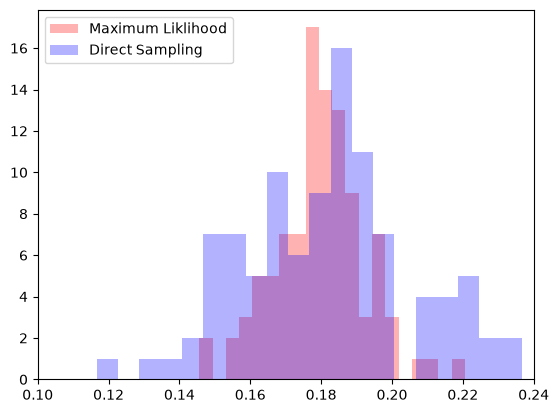

In [27]:
plt.figure()
plt.hist(ans_list, bins=20,alpha=0.3, color='r', label="Maximum Liklihood")
plt.hist(ans_list2, bins=20,alpha=0.3, color='b', label="Direct Sampling")

plt.xlim([0.1, 0.24])
plt.legend()
plt.show()


It can be confirmed that the method using maximum likelihood estimation is able to estimate the data with less variance.  
In summary, we were able to perform numerical integration by quantum amplitude estimation without quantum phase estimation.

In maximum likelihood estimation, we need to take into account the amount of computation required to maximize the likelihood function and the existence of local maxima.  
In the implementation example above, if the number of optuna's trials n_trials is reduced, the maximum likelihood estimation gets stuck in the local solution and the estimation accuracy deteriorates significantly.